# Belgian Air Quality: Predicting Elevated PM2.5 Tomorrow
**Classification capstone · Simona Barbuceanu · October 2026**

Driving question: How can a classification model make a measurable difference while remaining transparent, fair and reliable?

This notebook integrates the problem, data, preprocessing, models, optimization, ethics and impact. All plots and results are embedded after execution. The bundled data enable offline reproduction. This is an educational retrospective forecasting experiment for community air quality.

**Evaluation history:** Logistic regression was trained on 2022–2023, selected on 2024, and evaluated on 2025 before this notebook was assembled. The original frozen model remains the primary reported model. A nonlinear comparator and feature refinement added for this submission are selected only on 2024; their 2025 results are explicitly exploratory, since the holdout had already been seen. They do not replace the primary model based on test performance.

## 1. Problem Definition & Context

**Binary problem:** at 23:00 Europe/Brussels, predict whether the following local calendar day's eligible station PM2.5 mean is strictly greater than 15 µg/m³. Class 1 means elevated, class 0 means not elevated by this analytical rule. Incomplete target days remain unlabelled.

**Hypothesis:** recent PM2.5 levels, changes and calendar information contain predictive signals for next-day elevated levels, and a classifier can detect more elevated days than persistence. This hypothesis is tested against explicit baselines, with precision and recall reported together.

**Purpose and stakeholders:** local environmental teams could review potential pollution warnings and help communities plan activities. Monitoring agencies supply measurements; municipal teams review evidence; residents benefit from clearer information. The model predicts outdoor station measurements, not personal exposure or symptoms.

**5W+H:** Who: environmental and municipal analysts. What: review a potential elevated-day flag. When: 23:00 for tomorrow. Where: the 60 selected Belgian stations. Why: assess whether historical signals improve on persistence. How: chronological evaluation of F2, recall, precision and F1, alongside false-alarm volume and station-level diagnostics. No health benefit or real-world impact has yet been measured.

**Cutoff:** evidence cutoff 22:00 is an assumed one-hour publication buffer. With daily inputs, today is unfinished: the latest completed day is yesterday, two days before the target. Example: forecast 10 January at 23:00, target 11 January, latest daily average 9 January. Live availability and revision timing are unvalidated. No automatic warning deployment is proposed.

## 2. Dataset Selection & Description

Real Belgian station measurements, 2022–2025, supplied by **IRCEL–CELINE** and reconciled against official Belgian EEA E1a reporting records. **Why this dataset:** it offers several years of real, openly licensed, quality-verified measurements, with enough labelled examples (85,734) and positive cases (well above 100 per class) for a reliable chronological evaluation. The target matters for public health communication, and it can be derived transparently from the measurements themselves rather than from subjective labels.

**Sources and access:** [IRCEL open data](https://www.irceline.be/en/documentation/open-data), [historical measurement endpoint documentation](https://github.com/irceline/open_data/blob/master/datasets/measurements.md), [Belgian official E1a reporting](https://cdr.eionet.europa.eu/be/eu/aqd/e1a/). The bundled manifest records exact original URLs and hashes. Provider open data are published under **CC BY 4.0**; credit IRCEL–CELINE and acknowledge our aggregation and derived labels. No personal or health data are included.

**Target rationale:** the analytical >15 µg/m³ rule is informed by the [WHO 2021 guidelines](https://www.who.int/publications/i/item/9789240034228). It is not a complete WHO compliance assessment, legal limit, or safe/unsafe boundary.

**Prepared file:** one row per station and Belgian calendar day, with daily concentration, eligibility, coverage and derived target. The 60-station panel is selected using ≥90% verified hourly coverage in both training years only. 87,660 calendar station-days; 85,734 labelled rows across all years. 43,168 labelled training rows contain 7,431 elevated examples. These are correlated observations across dates and stations, not independent events.

**Concerns:** class imbalance, monitoring-network coverage bias, seasonal shifts, retrospective data revisions and missingness. Numeric predictors are lagged concentration, rolling level/variability, trends, completeness and known calendar features. Station identifiers remain metadata; no demographics are inferred.

In [1]:
from pathlib import Path
import json, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    accuracy_score,
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    brier_score_loss,
)
from sklearn.inspection import permutation_importance
from sklearn.exceptions import ConvergenceWarning
import joblib

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False})
raw = pd.read_csv(DATA / "pm25_daily_belgian_time.csv", parse_dates=["local_date"])
print("Source SHA-256:", hashlib.sha256((DATA / "pm25_daily_belgian_time.csv").read_bytes()).hexdigest())
print("Rows:", len(raw), "| stations:", raw.series_id.nunique())
display(raw.head())
display(pd.read_json(DATA / "official_source_manifest.json")[["year", "file", "url", "sha256"]])

Source SHA-256: 0bc6520f1f61dbaa0d8e95b8450fe01e1a030ada3b93dbe3eb5e77d9d36ba107
Rows: 87660 | stations: 60


,local_date,expected_hours,valid_hours,mean_available_valid_hours,api_nonnegative_rejected_hours,official_value_differences,minimum_valid_hours,eligible,coverage_pct,daily_pm25_ug_m3,above_15,series_id,station,official_station_code,year,split
0,2022-01-01,24,24,11.182083,0,0,18,True,100.0,11.182083,0.0,100005,44RL01 - Roeselare,BELRL01,2022,train
1,2022-01-02,24,24,8.205417,0,0,18,True,100.0,8.205417,0.0,100005,44RL01 - Roeselare,BELRL01,2022,train
2,2022-01-03,24,24,6.462500,0,0,18,True,100.0,6.462500,0.0,100005,44RL01 - Roeselare,BELRL01,2022,train
3,2022-01-04,24,24,3.995000,0,0,18,True,100.0,3.995000,0.0,100005,44RL01 - Roeselare,BELRL01,2022,train
4,2022-01-05,24,24,6.501667,0,12,18,True,100.0,6.501667,0.0,100005,44RL01 - Roeselare,BELRL01,2022,train


,year,file,url,sha256
0,2021,E1a_BE_2021.xml,https://cdr.eionet.europa.eu/be/eu/aqd/e1a/env...,2535e0e771a0b516ac8bf6b68b20fba60430e271e7547c...
1,2022,E1a_BE_2022.xml,https://cdr.eionet.europa.eu/be/eu/aqd/e1a/env...,240324b227ad1b23408ac420e65af9d83e4b2d5c3efe12...
2,2022,E1a_BE_2022_eoi.xml,https://cdr.eionet.europa.eu/be/eu/aqd/e1a/env...,fba177511b5f825a7c9e0d661186f4c29ae995c1e8d8f7...
3,2023,E1a_BE_2023.xml,https://cdr.eionet.europa.eu/be/eu/aqd/e1a/env...,11c223ff7df16b12e4230893f8e8ff932d1ec4d3a55a62...
4,2023,E1a_BE_2023_add.xml,https://cdr.eionet.europa.eu/be/eu/aqd/e1a/env...,29f13ee1bcbeaec167065125f1f4e73cc455c396218092...
5,2023,E1a_BE_2023_eoi.xml,https://cdr.eionet.europa.eu/be/eu/aqd/e1a/env...,fc9b079da5fdbe9d0ae55afdf7a3e4f48ff300596bd09c...
6,2024,E1a_BE_2024.xml,https://cdr.eionet.europa.eu/be/eu/aqd/e1a/env...,6e774d9fde7def05dc87a8887b925d48a3891aa2b730ed...
7,2024,E1a_BE_2024_eoi.xml,https://cdr.eionet.europa.eu/be/eu/aqd/e1a/env...,6b992252874266f84b55754193751ef950b532880e27a4...
8,2025,E1a_BE_2025.xml,https://cdr.eionet.europa.eu/be/eu/aqd/e1a/env...,b47927c3e2cdcab6d1dc9b4aa827cf13a4d53c88688c60...
9,2025,E1a_BE_2025_eoi_complete.xml,https://cdr.eionet.europa.eu/be/eu/aqd/e1a/env...,4f5d066aa06f8fdcdbc003cf3d4992c2103a11ea8830c0...


## 3. Data Understanding & Preprocessing

**Cleaning already applied to hourly sources:** official verification flag 1, accepted validity flags 1/2/3, finite non-negative concentrations; actual retained records use validity 1. Invalid or unavailable hours excluded; official values replace conflicting API values. API timestamps mark interval end; local-day aggregation uses interval start. Distinct UTC hours preserve autumn's repeated local hour.

**Daily completeness:** ≥75% of expected local-day hours: 18 of 23, 18 of 24, 19 of 25. Ineligible days receive neither a modelling concentration nor target. Extreme positive concentrations are retained as potential events rather than automatically clipped. No target imputation. Preparation recovered 108,045 official observations absent from API and rejected 25,983 non-negative API values. Sixteen independent XML-based day checks, including clock changes and boundaries, passed in the prior preparation.

Below we verify the bundled daily table and explore **training years only** for modelling insights. Chronological splits replace random stratification: random splits would mix nearby days and shared pollution episodes, weakening the forward-prediction evaluation. Natural future class proportions are retained.

### Data pipeline: hourly to daily (reproducible step)
The bundled daily file comes from `src/hourly_to_daily.py`, which is included in the project. Starting from the reconciled official hourly file (`data/pm25_hourly_reconciled.csv.gz`), the script:
1. assigns each hour to its Belgian local day using its UTC interval start, so clock-change days have 23 or 25 expected hours;
2. keeps only hours with verification flag 1, validity 1/2/3 and a finite, non-negative value;
3. sums and counts valid hours per station-day across all file chunks before averaging, so chunk means are never averaged;
4. builds the complete station × calendar grid, so days with no data stay visible as missing;
5. labels a day only when at least 75% of its expected hours are valid, then sets `above_15` = daily mean > 15 µg/m³;
6. keeps the 60 stations with ≥90% hourly coverage in both training years (2022 and 2023), so the panel is chosen without looking at validation or test years.

**Full rebuild from the official source.** The hourly input is bundled (`data/pm25_hourly_reconciled.csv.gz`, 2,612,337 station-hours for 81 mapped stations). It can be regenerated from scratch with `src/e1a_to_hourly.py`, which downloads the six official Belgian E1a XML reports listed in `data/official_source_manifest.json` (about 1.1 GB), checks each file's SHA-256 hash, and extracts the hourly PM2.5 values with their verification and validity flags. Only official values are used. The extra API comparison columns in the bundled daily file (`api_nonnegative_rejected_hours`, `official_value_differences`) are documentation only, and the model does not use them. Their totals are in `data/reconciliation_summary.json`.

Run order from the project root: `python src/e1a_to_hourly.py` → `python src/hourly_to_daily.py` → this notebook. The rebuilt daily file was produced this way. The next cell shows that it matches the bundled modelling file exactly on every core column (station-day rows, expected and valid hours, eligibility, daily mean and label). The 16 independent XML day checks in `data/independent_verification.json` also pass.

In [2]:
# Optional reproducibility check: compare a rebuilt daily file (python src/hourly_to_daily.py) with the bundled one
verification = json.loads((DATA / "independent_verification.json").read_text())
xml_checks = verification["scalar_xml_checks"]
print(f"Independent XML day checks: {sum(c['pass'] for c in xml_checks)}/{len(xml_checks)} passed")
rebuilt_path = DATA / "pm25_daily_rebuilt.csv"
if rebuilt_path.exists():
    rebuilt = pd.read_csv(rebuilt_path, parse_dates=["local_date"])
    key = ["series_id", "local_date"]
    core = [
        "expected_hours",
        "valid_hours",
        "minimum_valid_hours",
        "eligible",
        "daily_pm25_ug_m3",
        "above_15",
    ]
    merged = raw[key + core].merge(
        rebuilt[key + core], on=key, how="outer", suffixes=("_bundled", "_rebuilt"), indicator=True
    )
    assert merged["_merge"].eq("both").all(), "Station-day rows differ between bundled and rebuilt files"
    for c in core:
        a, b = merged[f"{c}_bundled"], merged[f"{c}_rebuilt"]
        same = (
            np.isclose(a.astype(float), b.astype(float), equal_nan=True)
            if c == "daily_pm25_ug_m3"
            else a.astype("float").fillna(-1).eq(b.astype("float").fillna(-1))
        )
        assert np.all(same), f"Column {c} differs"
    print("Rebuilt daily file matches the bundled file on all core columns.")
else:
    print("No rebuilt file found; using the bundled daily file (authoritative modelling input).")

Independent XML day checks: 16/16 passed
Rebuilt daily file matches the bundled file on all core columns.


Training eligible: 43168 | elevated: 7431 | missing days: 632


,daily_pm25_ug_m3,coverage_pct
count,43168.000000,43168.000000
mean,9.447547,99.624228
std,7.688343,1.932970
min,0.000000,75.000000
25%,4.504167,100.000000
50%,7.402500,100.000000
75%,12.199778,100.000000
max,88.125000,100.000000


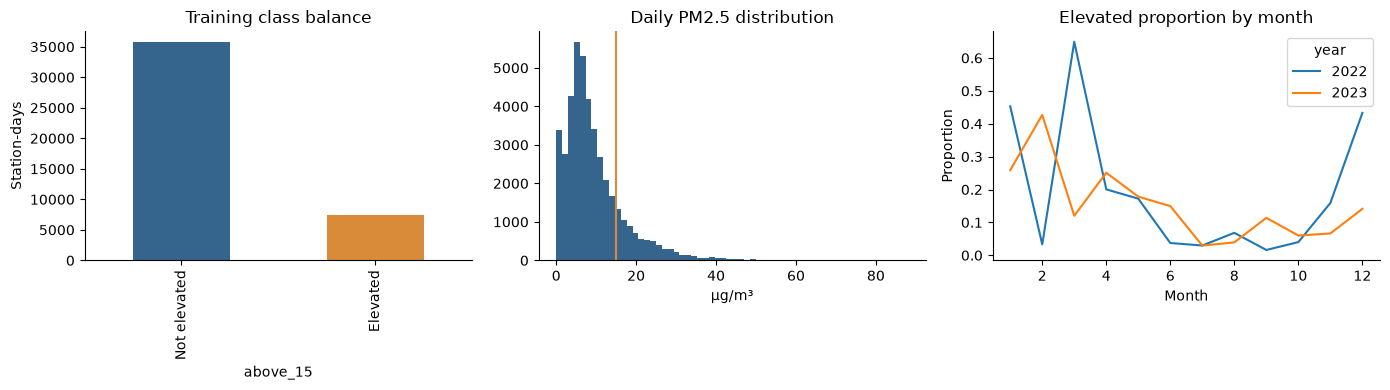

,size,mean
station,,
43N113 - Sainte-Ode,722,0.026316
40OB01 - Oostrozebeke,728,0.296703


March elevated proportion by year: {2022: 0.6493224932249323, 2023: 0.12021857923497267}


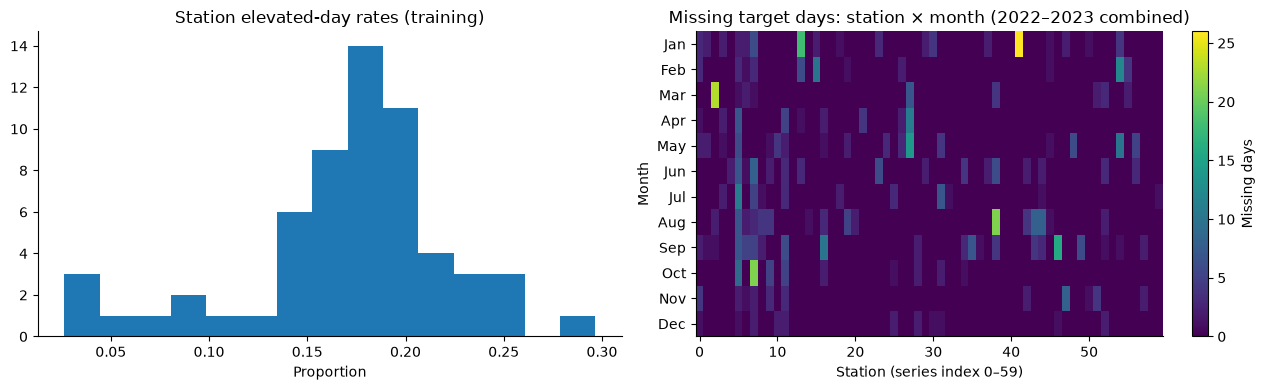

In [3]:
assert len(raw) == 87660 and raw.series_id.nunique() == 60
assert not raw.duplicated(["series_id", "local_date"]).any()
assert set(raw.expected_hours) == {23, 24, 25}
assert (raw.minimum_valid_hours == np.ceil(raw.expected_hours * 0.75)).all()
assert raw.eligible.equals(raw.valid_hours.ge(raw.minimum_valid_hours))
assert raw.loc[~raw.eligible, ["daily_pm25_ug_m3", "above_15"]].isna().all().all()
assert (
    raw.loc[raw.eligible, "above_15"].to_numpy()
    == (raw.loc[raw.eligible, "daily_pm25_ug_m3"] > 15).astype(int).to_numpy()
).all()
ed = raw[raw.year.isin([2022, 2023])].copy()
labelled = ed[ed.eligible]
print(
    "Training eligible:",
    len(labelled),
    "| elevated:",
    int(labelled.above_15.sum()),
    "| missing days:",
    int((~ed.eligible).sum()),
)
display(labelled[["daily_pm25_ug_m3", "coverage_pct"]].describe())
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
labelled.above_15.value_counts().sort_index().plot.bar(ax=ax[0], color=["#35658c", "#da8b39"])
ax[0].set(xticklabels=["Not elevated", "Elevated"], title="Training class balance", ylabel="Station-days")
ax[1].hist(labelled.daily_pm25_ug_m3, bins=60, color="#35658c")
ax[1].axvline(15, color="#da8b39")
ax[1].set(title="Daily PM2.5 distribution", xlabel="µg/m³")
monthly = labelled.groupby([labelled.local_date.dt.month, "year"]).above_15.mean().unstack()
monthly.plot(ax=ax[2])
ax[2].set(title="Elevated proportion by month", ylabel="Proportion", xlabel="Month")
plt.tight_layout()
plt.show()
station_eda = labelled.groupby("station").above_15.agg(["size", "mean"]).sort_values("mean")
display(station_eda.iloc[[0, -1]])
print("March elevated proportion by year:", monthly.loc[3].to_dict())
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(station_eda["mean"], bins=15)
ax[0].set(title="Station elevated-day rates (training)", xlabel="Proportion")
missing = (
    ed.assign(missing=~ed.eligible).groupby([ed.local_date.dt.month, "series_id"]).missing.sum().unstack()
)
im = ax[1].imshow(missing, aspect="auto")
ax[1].set(
    title="Missing target days: station × month (2022–2023 combined)",
    xlabel="Station (series index 0–59)",
    ylabel="Month",
)
ax[1].set_yticks(
    range(12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
fig.colorbar(im, ax=ax[1], label="Missing days")
plt.tight_layout()
plt.show()

**EDA interpretation:** 17.2% of eligible training days are elevated, so accuracy alone can reward predicting no events. March differs sharply between years (64.9% versus 12.0%); calendar signals are candidates, not reliable repeating rules. Station rates range from 2.6% to 29.7%, while 632 missing training target days cluster by station/date. Preserve the calendar grid and analyse station variation. Two training years cannot establish stable seasonality.

### Reproducible feature engineering
Shift within station on the complete calendar. Lags are exact calendar days. Windows end at target minus two and require all daily values for means/std; availability counts and a latest-lag missing flag preserve missingness. Trends compare recent days with earlier days. Annual sine/cosine phase accounts for leap years; weekday and weekend are known ahead of time. Do not include target concentration, target coverage or quality flags in predictors.

Calendar and future-mutation checks passed.


,count,mean,std,min,max
pm25_lag_2d,42690.0,9.469954,7.698235,0.000000,88.125000
pm25_lag_3d,42571.0,9.481026,7.705081,0.000000,88.125000
pm25_lag_4d,42475.0,9.489683,7.708269,0.000000,88.125000
pm25_lag_7d,42247.0,9.503184,7.710010,0.000000,88.125000
pm25_lag_14d,41795.0,9.537364,7.727312,0.000000,88.125000
pm25_mean_3d,42126.0,9.491661,6.825869,0.000000,60.616944
pm25_std_3d,42126.0,2.665831,2.420921,0.000000,25.452349
valid_days_3d,43168.0,2.959044,0.288448,0.000000,3.000000
pm25_mean_7d,41080.0,9.530330,6.018384,0.006420,43.791131
pm25_std_7d,41080.0,3.988220,2.808173,0.015046,27.006691


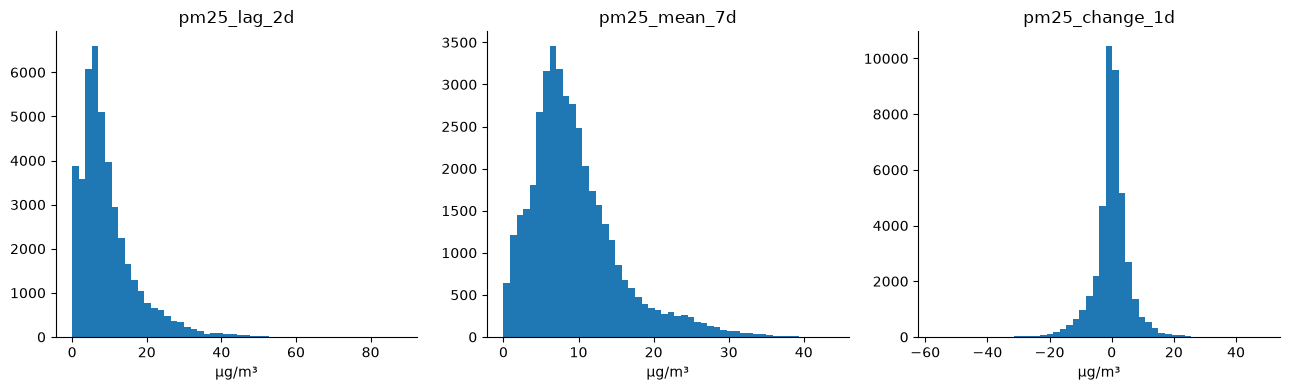

Missing predictor cells: 21855


In [4]:
def build(raw):
    parts = []
    for sid, g in raw.groupby("series_id", sort=True):
        g = g.sort_values("local_date").set_index("local_date")
        assert not g.index.duplicated().any()
        g = g.reindex(pd.date_range("2022-01-01", "2025-12-31", freq="D"))
        s = g.daily_pm25_ug_m3.where(g.eligible.eq(True))
        f = pd.DataFrame(index=g.index)
        f["series_id"] = sid
        f["station"] = g.station.dropna().iloc[0]
        f["target_above_15"] = g.above_15
        f["target_date"] = f.index.strftime("%Y-%m-%d")
        f["forecast_time_local"] = (
            (f.index - pd.Timedelta(days=1) + pd.Timedelta(hours=23))
            .tz_localize("Europe/Brussels")
            .astype(str)
        )
        f["evidence_cutoff_local"] = (
            (f.index - pd.Timedelta(days=1) + pd.Timedelta(hours=22))
            .tz_localize("Europe/Brussels")
            .astype(str)
        )
        f["latest_daily_source_date"] = (f.index - pd.Timedelta(days=2)).strftime("%Y-%m-%d")
        f["split"] = np.where(
            f.index.year <= 2023, "train", np.where(f.index.year == 2024, "validation", "test")
        )
        for lag in [2, 3, 4, 7, 14]:
            f[f"pm25_lag_{lag}d"] = s.shift(lag)
        past = s.shift(2)
        for w in [3, 7, 14]:
            roll = past.rolling(w, min_periods=w)
            f[f"pm25_mean_{w}d"] = roll.mean()
            f[f"pm25_std_{w}d"] = roll.std(ddof=0)
            f[f"valid_days_{w}d"] = past.rolling(w, min_periods=1).count().fillna(0)
        f["pm25_change_1d"] = s.shift(2) - s.shift(3)
        f["pm25_change_7d"] = s.shift(2) - s.shift(9)
        f["pm25_trend_3_vs_previous_3d"] = (
            past.rolling(3, min_periods=3).mean() - s.shift(5).rolling(3, min_periods=3).mean()
        )
        f["lag2_missing"] = s.shift(2).isna().astype(int)
        f["target_weekday_sin"] = np.sin(2 * np.pi * f.index.dayofweek / 7)
        f["target_weekday_cos"] = np.cos(2 * np.pi * f.index.dayofweek / 7)
        phase = (f.index.dayofyear - 1) / np.where(f.index.is_leap_year, 366, 365)
        f["target_year_sin"] = np.sin(2 * np.pi * phase)
        f["target_year_cos"] = np.cos(2 * np.pi * phase)
        f["target_is_weekend"] = (f.index.dayofweek >= 5).astype(int)
        parts.append(f.reset_index(drop=True))
    return pd.concat(parts, ignore_index=True)


frame = build(raw)
metadata = [
    "series_id",
    "station",
    "target_above_15",
    "target_date",
    "forecast_time_local",
    "evidence_cutoff_local",
    "latest_daily_source_date",
    "split",
]
features = [c for c in frame if c not in metadata]
assert len(features) == 23 and len(frame) == 87660
# Prove unavailable future pollution cannot influence a selected target's predictors.
sid = raw.series_id.iloc[0]
for date in ["2022-03-27", "2023-10-29", "2024-01-01", "2025-01-01"]:
    changed = raw[raw.series_id.eq(sid)].copy()
    changed.loc[changed.local_date.ge(pd.Timestamp(date) - pd.Timedelta(days=1)), "daily_pm25_ug_m3"] = 9999
    alternate = build(changed)
    a = frame.loc[frame.series_id.eq(sid) & frame.target_date.eq(date), features].reset_index(drop=True)
    b = alternate.loc[alternate.target_date.eq(date), features].reset_index(drop=True)
    pd.testing.assert_frame_equal(a, b)
print("Calendar and future-mutation checks passed.")
train = frame[frame.split.eq("train") & frame.target_above_15.notna()].copy()
val = frame[frame.split.eq("validation") & frame.target_above_15.notna()].copy()
X = train[features]
y = train.target_above_15.astype(int)
V = val[features]
vy = val.target_above_15.astype(int)
assert pd.to_datetime(train.target_date).max() < pd.to_datetime(val.target_date).min()
display(X.describe().T[["count", "mean", "std", "min", "max"]])
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, c in zip(ax, ["pm25_lag_2d", "pm25_mean_7d", "pm25_change_1d"]):
    a.hist(X[c].dropna(), bins=50)
    a.set(title=c, xlabel="µg/m³")
plt.tight_layout()
plt.show()
print("Missing predictor cells:", int(X.isna().sum().sum()))

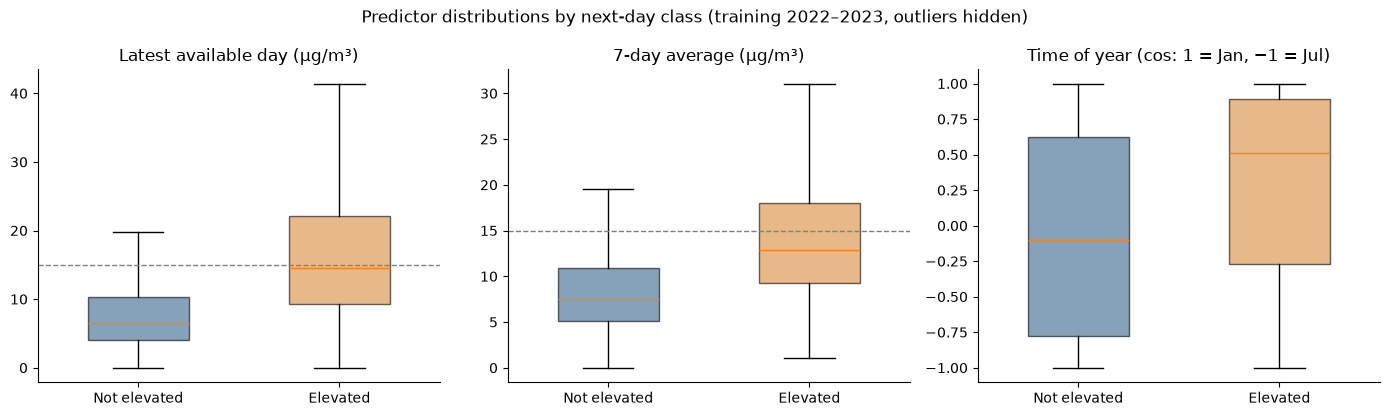

,pm25_lag_2d,pm25_mean_7d,target_year_cos
target_above_15,,,
Not elevated,6.52,7.55,-0.10
Elevated,14.52,12.89,0.51


Elevated rate when latest day >15: 48.0% (n=7390); when ≤15: 10.8%


In [5]:
# EDA: how do key predictors differ between elevated and normal target days? (training years only)
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
for a, (c, label) in zip(
    ax,
    [
        ("pm25_lag_2d", "Latest available day (µg/m³)"),
        ("pm25_mean_7d", "7-day average (µg/m³)"),
        ("target_year_cos", "Time of year (cos: 1 = Jan, −1 = Jul)"),
    ],
):
    data = [X.loc[y.eq(k), c].dropna() for k in (0, 1)]
    box = a.boxplot(data, showfliers=False, widths=0.5, patch_artist=True)
    for patch, col in zip(box["boxes"], ["#35658c", "#da8b39"]):
        patch.set(facecolor=col, alpha=0.6)
    a.set_xticks([1, 2], ["Not elevated", "Elevated"])
    a.set(title=label)
    if c != "target_year_cos":
        a.axhline(15, color="grey", ls="--", lw=1)
plt.suptitle("Predictor distributions by next-day class (training 2022–2023, outliers hidden)")
plt.tight_layout()
plt.show()
by_class = (
    X.groupby(y)[["pm25_lag_2d", "pm25_mean_7d", "target_year_cos"]]
    .median()
    .rename(index={0: "Not elevated", 1: "Elevated"})
)
display(by_class.round(2))
high = X.pm25_lag_2d > 15
print(
    f"Elevated rate when latest day >15: {y[high].mean():.1%} (n={int(high.sum())}); when ≤15: {y[X.pm25_lag_2d.le(15)].mean():.1%}"
)

**Predictors by class:** elevated target days follow clearly higher recent readings. The median latest available day is 14.5 µg/m³ before elevated days and 6.5 µg/m³ before normal days, and the median 7-day average is 12.9 versus 7.6. When the latest available day exceeded 15 µg/m³, 48.0% of next-day targets were elevated, compared with 10.8% otherwise. This is the persistence signal, and it is why persistence is the main baseline. The overlap is still large: about a quarter of elevated days followed a latest reading below roughly 9 µg/m³. Low recent readings may make some elevated days harder to anticipate. Missing weather inputs may contribute to these errors; this hypothesis requires further testing. Elevated days lean towards winter (median annual cosine 0.51 versus −0.10), which supports including calendar features. The unstable March pattern above warns against trusting them too much.

**Preprocessing:** median imputation with indicators and standard scaling are fitted only on training data inside logistic pipelines. Random Forest uses training-only imputation and does not require scaling. Cyclical numeric encoding avoids arbitrary ordering of calendar categories. Station ID is excluded to focus on shared patterns, so unseen-station generalization remains untested. The start of 2022 lacks prior history; no backfill is used. Missing-label rows are excluded only after creating calendar-based features.

## 4. Model Development

**Models:** persistence (latest eligible completed day >15; training-majority fallback when missing), logistic regression (interpretable linear baseline), and Random Forest (nonlinear interactions). Include always-non-elevated and always-elevated comparators.

**Main tuning:** the prior logistic pass used weights none, positive 2/4/8, balanced, and thresholds 0.00–1.00 at steps of 0.01, selecting maximum validation F2 with precision/recall tie breaks. C=1 remained fixed. Reproduce all five fits here and check the frozen winning configuration. Random Forest receives a modest four-configuration depth/leaf search and the same threshold grid on 2024 only. Its results are exploratory additions after the original final test had been seen.

F2 prioritises recall; precision and F1 show the cost of that choice. Average precision is the reported PR-AUC summary; ROC AUC is also shown. Weighted scores are not assumed calibrated probabilities.

In [6]:
def metric_row(name, actual, predicted, scores=None):
    tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0, 1]).ravel()
    r = {
        "model": name,
        "precision": precision_score(actual, predicted, zero_division=0),
        "recall": recall_score(actual, predicted, zero_division=0),
        "f1": f1_score(actual, predicted, zero_division=0),
        "f2": fbeta_score(actual, predicted, beta=2, zero_division=0),
        "accuracy": accuracy_score(actual, predicted),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "alerts": int(sum(predicted)),
    }
    if scores is not None:
        r.update(
            average_precision=average_precision_score(actual, scores), roc_auc=roc_auc_score(actual, scores)
        )
    return r


thresholds = np.linspace(0, 1, 101)


def threshold_search(name, scores):
    return pd.DataFrame(
        [
            dict(config=name, threshold=float(t), **metric_row(name, vy, (scores >= t).astype(int)))
            for t in thresholds
        ]
    )


def best_row(grid):
    return grid.sort_values(["f2", "precision", "recall"], ascending=False, kind="stable").iloc[0]


def fit_checked(model, inputs=X):
    with warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        model.fit(inputs, y)
    assert np.allclose(model["imputer"].statistics_, inputs.median())
    if "scaler" in model.named_steps:
        assert np.all(np.asarray(model["scaler"].n_samples_seen_) == len(train))
    return model


weights = [
    ("none", None),
    ("positive_2", {0: 1, 1: 2}),
    ("positive_4", {0: 1, 1: 4}),
    ("balanced", "balanced"),
    ("positive_8", {0: 1, 1: 8}),
]
log_models = {}
log_grids = []
for name, w in weights:
    model = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(C=1, max_iter=2000, class_weight=w, random_state=42)),
        ]
    )
    log_models[name] = fit_checked(model)
    log_grids.append(threshold_search(name, model.predict_proba(V)[:, 1]))
log_grid = pd.concat(log_grids, ignore_index=True)
log_best = best_row(log_grid)
assert log_best.config == "positive_8" and np.isclose(log_best.threshold, 0.4)
frozen = joblib.load(DATA / "frozen_logistic.joblib")
assert np.allclose(frozen.predict_proba(V), log_models["positive_8"].predict_proba(V))
log_grid.to_csv(RESULTS / "logistic_validation_grid.csv", index=False)
display(
    log_grid.sort_values("f2", ascending=False)
    .groupby("config")
    .head(1)[["config", "threshold", "precision", "recall", "f1", "f2"]]
)
rf_models = {}
rf_grids = []
for depth, leaf in [(10, 5), (10, 20), (None, 5), (None, 20)]:
    name = f"RF_depth_{depth}_leaf_{leaf}"
    rf = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=100,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    class_weight="balanced",
                    max_features="sqrt",
                    random_state=42,
                    n_jobs=2,
                ),
            ),
        ]
    )
    rf_models[name] = fit_checked(rf)
    rf_grids.append(threshold_search(name, rf.predict_proba(V)[:, 1]))
rf_grid = pd.concat(rf_grids, ignore_index=True)
rf_best = best_row(rf_grid)
rf_selected = rf_models[rf_best.config]
rf_threshold = float(rf_best.threshold)
rf_grid.to_csv(RESULTS / "rf_validation_grid.csv", index=False)
display(
    rf_grid.sort_values("f2", ascending=False)
    .groupby("config")
    .head(1)[["config", "threshold", "precision", "recall", "f1", "f2"]]
)
vp = frozen.predict_proba(V)[:, 1]
vr = rf_selected.predict_proba(V)[:, 1]
persist_val = np.where(V.pm25_lag_2d.isna(), 0, (V.pm25_lag_2d > 15).astype(int))
validation = pd.DataFrame(
    [
        metric_row("Persistence", vy, persist_val),
        metric_row("Logistic default", vy, (log_models["none"].predict_proba(V)[:, 1] >= 0.5).astype(int)),
        metric_row("Frozen logistic", vy, (vp >= 0.4).astype(int), vp),
        metric_row("RF exploratory", vy, (vr >= rf_threshold).astype(int), vr),
    ]
)
validation.to_csv(RESULTS / "validation_models.csv", index=False)
display(validation)

,config,threshold,precision,recall,f1,f2
444,positive_8,0.40,0.178499,0.825804,0.293547,0.478651
334,balanced,0.31,0.180631,0.799349,0.294674,0.474373
229,positive_4,0.27,0.178442,0.803826,0.292052,0.472578
116,positive_2,0.15,0.169165,0.822141,0.280595,0.463963
10,none,0.10,0.175673,0.759463,0.285343,0.456235


,config,threshold,precision,recall,f1,f2
30,RF_depth_10_leaf_5,0.30,0.231589,0.707774,0.348987,0.501529
320,RF_depth_None_leaf_20,0.17,0.186902,0.858364,0.306965,0.499479
122,RF_depth_10_leaf_20,0.21,0.187472,0.838014,0.306399,0.494690
216,RF_depth_None_leaf_5,0.14,0.193802,0.791616,0.311374,0.489579


,model,precision,recall,f1,f2,accuracy,tn,fp,fn,tp,alerts,average_precision,roc_auc
0,Persistence,0.311859,0.309320,0.310584,0.309825,0.841529,17157,1677,1697,760,2437,NaN,NaN
1,Logistic default,0.308190,0.058201,0.097912,0.069471,0.876239,18513,321,2314,143,464,NaN,NaN
2,Frozen logistic,0.178499,0.825804,0.293547,0.478651,0.541309,9496,9338,428,2029,11367,0.258648,0.737559
3,RF exploratory,0.231589,0.707774,0.348987,0.501529,0.695270,13064,5770,718,1739,7509,0.261544,0.754760


## 5. Model Evaluation, Optimization & Ethics

### Light refinement and confirmation
Test a smaller logistic feature set containing exact lags, completeness and calendar information, removing overlapping rolling summaries and trends. Select its threshold using 2024 only. This is a feature-refinement experiment, not a change to the previously frozen primary model. Confirmation also checks that the original weighted logistic parameters reproduce its saved predictions.

,candidate,features,threshold,model,precision,recall,f1,f2,accuracy,tn,fp,fn,tp,alerts
0,Full frozen logistic,23,0.40,Full,0.178499,0.825804,0.293547,0.478651,0.541309,9496,9338,428,2029,11367
1,Reduced exploratory,11,0.41,Reduced,0.184668,0.807896,0.300621,0.482335,0.566202,10070,8764,472,1985,10749


Primary model remains frozen. New candidate choice is not based on 2025.


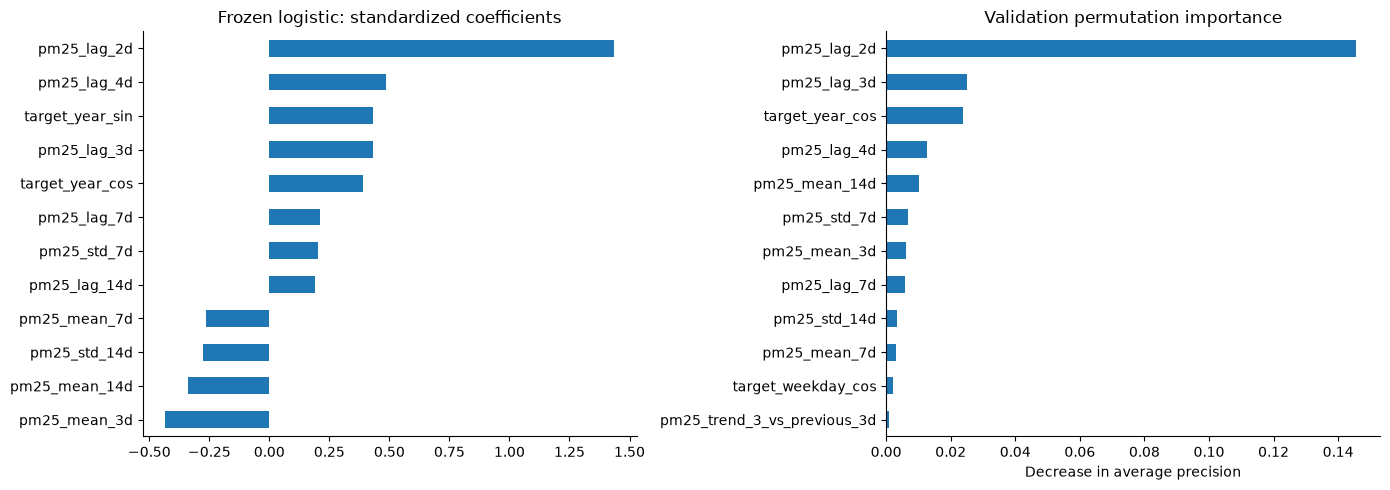

Overlapping lag/rolling features can share importance; coefficients do not prove causation.


In [7]:
reduced = [c for c in features if c.startswith("pm25_lag_") or c.startswith("target_") or c == "lag2_missing"]
refined = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(C=1, max_iter=2000, class_weight={0: 1, 1: 8}, random_state=42)),
    ]
)
fit_checked(refined, X[reduced])
reduced_grid = threshold_search("Reduced logistic", refined.predict_proba(V[reduced])[:, 1])
reduced_best = best_row(reduced_grid)
display(
    pd.DataFrame(
        [
            dict(
                candidate="Full frozen logistic",
                features=len(features),
                threshold=0.4,
                **metric_row("Full", vy, (vp >= 0.4).astype(int))
            ),
            dict(
                candidate="Reduced exploratory",
                features=len(reduced),
                threshold=float(reduced_best.threshold),
                **metric_row(
                    "Reduced",
                    vy,
                    (refined.predict_proba(V[reduced])[:, 1] >= reduced_best.threshold).astype(int),
                )
            ),
        ]
    )
)
print("Primary model remains frozen. New candidate choice is not based on 2025.")
# Coefficients are conditional associations, not causal effects.
coef = pd.Series(frozen["classifier"].coef_[0], index=frozen["imputer"].get_feature_names_out(features))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
coef.reindex(coef.abs().nlargest(12).index).sort_values().plot.barh(ax=ax[0])
ax[0].set(title="Frozen logistic: standardized coefficients")
# Validation permutation importance uses continuous-score average precision, not test data.
importance = permutation_importance(
    frozen, V, vy, scoring="average_precision", n_repeats=3, random_state=42, n_jobs=2
)
imp = pd.Series(importance.importances_mean, index=features).sort_values()
imp.tail(12).plot.barh(ax=ax[1])
ax[1].set(title="Validation permutation importance", xlabel="Decrease in average precision")
plt.tight_layout()
plt.show()
coef.rename("coefficient").to_csv(RESULTS / "logistic_coefficients.csv")
imp.rename("importance").to_csv(RESULTS / "validation_permutation_importance.csv")
print("Overlapping lag/rolling features can share importance; coefficients do not prove causation.")

**Refinement result (2024 validation only):** removing the 12 overlapping rolling-window and trend features (23 → 11 inputs) barely changed performance. At its validation-selected threshold of 0.41, the reduced model caught 1,985 elevated station-days against 2,029 for the full model (recall 80.8% versus 82.6%). It raised 574 fewer false alarms (8,764 versus 9,338, precision 18.5% versus 17.8%), and F2 was almost identical (0.482 versus 0.479). Most of the predictive signal therefore comes from the exact lags and calendar terms, and the rolling summaries mainly add redundancy. This redundancy also explains why some rolling means receive negative coefficients in the full model: they act as corrections to strongly correlated lags, so individual coefficient signs should not be read on their own. The simpler model is easier to explain and is the leading candidate for the next fresh-data test. Following the evaluation protocol, it does not replace the frozen primary model.

### Final testing and transparent evaluation history
2025 was first used for the frozen logistic model before capstone assembly. Reproducing its metrics is a confirmation. RF and reduced-model 2025 results below are **exploratory post-holdout comparisons**, even though their fits and selections use only 2022–2024. No claim of a fresh unbiased holdout is made for these additions. Model and preprocessing remain fitted on 2022–2023, without refitting on validation.

**Explainability finding:** the latest completed pollution level (lag two days relative to the target) has the greatest validation permutation importance. This supports persistence as a meaningful comparator. The reliability plot below shows that weighted logistic scores overstate observed event frequencies, reinforcing the need for calibration before presenting scores as probabilities.

,model,precision,recall,f1,f2,accuracy,tn,fp,fn,tp,alerts,average_precision,roc_auc
0,Persistence,0.498892,0.493116,0.495987,0.494261,0.849448,16496,1583,1620,1576,3159,NaN,NaN
1,Frozen logistic (primary),0.273600,0.900501,0.419686,0.617517,0.625899,10438,7641,318,2878,10519,0.507805,0.843926
2,RF (exploratory),0.324751,0.824781,0.466013,0.630592,0.716052,12598,5481,560,2636,8117,0.507904,0.849459
3,Reduced logistic (exploratory),0.278375,0.907071,0.426010,0.624838,0.632808,10564,7515,297,2899,10414,0.522680,0.855196
4,Always non-elevated,0.000000,0.000000,0.000000,0.000000,0.849777,18079,0,3196,0,0,NaN,NaN
5,Always elevated,0.150223,1.000000,0.261207,0.469186,0.150223,0,18079,0,3196,21275,NaN,NaN


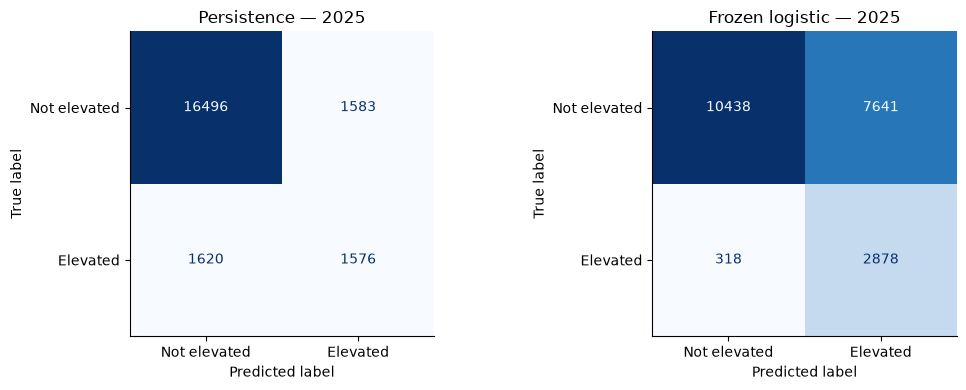

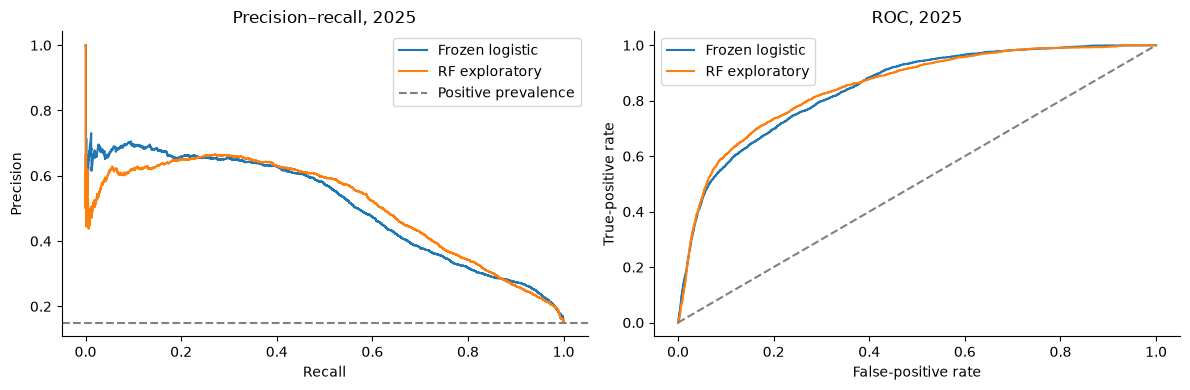

In [8]:
test = frame[frame.split.eq("test") & frame.target_above_15.notna()].copy()
T = test[features]
ty = test.target_above_15.astype(int)
assert set(pd.to_datetime(test.target_date).dt.year) == {2025}
tp = frozen.predict_proba(T)[:, 1]
tr = rf_selected.predict_proba(T)[:, 1]
treduced = refined.predict_proba(T[reduced])[:, 1]
persist = np.where(T.pm25_lag_2d.isna(), 0, (T.pm25_lag_2d > 15).astype(int))
final = pd.DataFrame(
    [
        metric_row("Persistence", ty, persist),
        metric_row("Frozen logistic (primary)", ty, (tp >= 0.4).astype(int), tp),
        metric_row("RF (exploratory)", ty, (tr >= rf_threshold).astype(int), tr),
        metric_row(
            "Reduced logistic (exploratory)", ty, (treduced >= reduced_best.threshold).astype(int), treduced
        ),
        metric_row("Always non-elevated", ty, np.zeros(len(ty), dtype=int)),
        metric_row("Always elevated", ty, np.ones(len(ty), dtype=int)),
    ]
)
final.to_csv(RESULTS / "test_models.csv", index=False)
display(final)
assert np.isclose(final.iloc[1].recall, 2878 / 3196)
assert np.isclose(final.iloc[1].precision, 2878 / 10519)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, name, prediction in zip(ax, ["Persistence", "Frozen logistic"], [persist, (tp >= 0.4).astype(int)]):
    ConfusionMatrixDisplay.from_predictions(
        ty,
        prediction,
        display_labels=["Not elevated", "Elevated"],
        ax=a,
        colorbar=False,
        cmap="Blues",
        values_format="d",
    )
    a.set_title(name + " — 2025")
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, scores in [("Frozen logistic", tp), ("RF exploratory", tr)]:
    precision, recall, _ = precision_recall_curve(ty, scores)
    ax[0].plot(recall, precision, label=name)
    fpr, tpr, _ = roc_curve(ty, scores)
    ax[1].plot(fpr, tpr, label=name)
ax[0].axhline(ty.mean(), color="grey", ls="--", label="Positive prevalence")
ax[0].set(xlabel="Recall", ylabel="Precision", title="Precision–recall, 2025")
ax[1].plot([0, 1], [0, 1], "--", color="grey")
ax[1].set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC, 2025")
for a in ax:
    a.legend()
plt.tight_layout()
plt.show()

,station,positives,precision,recall,f1
19,43N113 - Sainte-Ode,10,0.067961,0.700000,0.123894
17,43N093 - Sinsin,25,0.147541,0.720000,0.244898
15,43N073 - Vezin,42,0.264000,0.785714,0.395210
11,43M204 - Angleur,29,0.198276,0.793103,0.317241
20,43N121 - Offagne,10,0.075472,0.800000,0.137931
31,45R511 - Marcinelle,48,0.268966,0.812500,0.404145
22,43R221 - Liège,49,0.283688,0.816327,0.421053
18,43N100 - Dourbes,17,0.122807,0.823529,0.213740
10,43H201 - Liège,40,0.244444,0.825000,0.377143
32,45R512 - Marchienne,63,0.325153,0.841270,0.469027


Station recall range: 0.7 1.0


,month,precision,recall,f1
0,1,0.376218,0.993139,0.545712
1,2,0.532238,0.963387,0.685668
2,3,0.413934,0.937666,0.574330
3,4,0.182492,0.937716,0.305524
4,5,0.067372,0.909091,0.125448
5,6,0.074830,0.868421,0.137787
6,7,0.000000,0.000000,0.000000
7,8,0.287293,0.722222,0.411067
8,9,0.272727,0.272727,0.272727
9,10,0.151042,0.429630,0.223507


False negatives with actual mean >25 µg/m³: 46


,series_id,station,target_date,target_above_15,score,prediction,actual_pm25,outcome
9945,6553,41MEU1 - Meudon,2025-03-25,1.0,0.337445,0,50.089967,False negative
87378,100034,41REG1 - Brussel (Bld du Régent),2025-03-25,1.0,0.333259,0,48.143467,False negative
21633,6920,43N070 - Mons,2025-03-25,1.0,0.374006,0,47.517771,False negative
65463,11042,40SZ05 - Steenokkerzeel,2025-03-25,1.0,0.398996,0,47.348583,False negative
8484,6532,41B011 - Berchem-Sainte-Agathe,2025-03-25,1.0,0.339327,0,47.221742,False negative


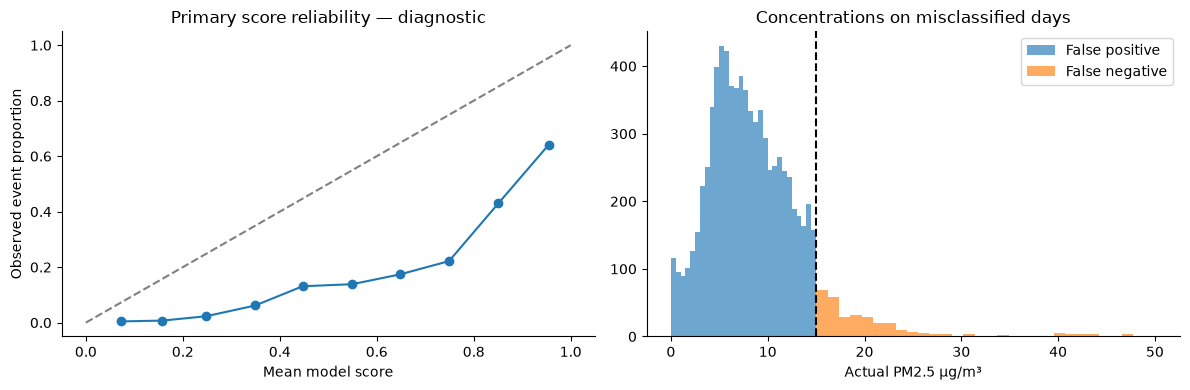

Brier score (uncalibrated weighted score): 0.20367103254827576


In [9]:
diagnostic = test[["series_id", "station", "target_date", "target_above_15"]].copy()
diagnostic["score"] = tp
diagnostic["prediction"] = (tp >= 0.4).astype(int)
diagnostic["actual_pm25"] = (
    raw.set_index(["series_id", "local_date"])
    .daily_pm25_ug_m3.reindex(pd.MultiIndex.from_arrays([test.series_id, pd.to_datetime(test.target_date)]))
    .to_numpy()
)
diagnostic["outcome"] = np.select(
    [
        (diagnostic.prediction == 1) & (diagnostic.target_above_15 == 0),
        (diagnostic.prediction == 0) & (diagnostic.target_above_15 == 1),
    ],
    ["False positive", "False negative"],
    default="Correct",
)
diagnostic.to_csv(RESULTS / "primary_test_predictions.csv", index=False)
station_rows = []
for sid, g in diagnostic.groupby("series_id"):
    station_rows.append(
        dict(
            station=g.station.iloc[0],
            positives=int(g.target_above_15.sum()),
            **metric_row(str(sid), g.target_above_15.astype(int), g.prediction)
        )
    )
station_metrics = pd.DataFrame(station_rows)
station_metrics.to_csv(RESULTS / "station_diagnostics.csv", index=False)
display(station_metrics[["station", "positives", "precision", "recall", "f1"]].sort_values("recall").head(10))
print("Station recall range:", station_metrics.recall.min(), station_metrics.recall.max())
# Diagnostic-only slices; never change thresholds based on test-year slices.
slices = []
for month, g in diagnostic.groupby(pd.to_datetime(diagnostic.target_date).dt.month):
    slices.append(dict(month=month, **metric_row(str(month), g.target_above_15.astype(int), g.prediction)))
display(pd.DataFrame(slices)[["month", "precision", "recall", "f1"]])
print(
    "False negatives with actual mean >25 µg/m³:",
    len(diagnostic[(diagnostic.outcome == "False negative") & (diagnostic.actual_pm25 > 25)]),
)
display(diagnostic[diagnostic.outcome.eq("False negative")].nlargest(5, "actual_pm25"))
# Reliability by score bins: weighted scores are not calibrated probabilities.
cal = diagnostic.groupby(pd.cut(diagnostic.score, bins=np.linspace(0, 1, 11)), observed=True).agg(
    mean_score=("score", "mean"), event_rate=("target_above_15", "mean"), n=("score", "size")
)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(cal.mean_score, cal.event_rate, "o-")
ax[0].plot([0, 1], [0, 1], "--", color="grey")
ax[0].set(
    title="Primary score reliability — diagnostic",
    xlabel="Mean model score",
    ylabel="Observed event proportion",
)
ax[1].hist(
    diagnostic[diagnostic.outcome.eq("False positive")].actual_pm25,
    bins=30,
    alpha=0.65,
    label="False positive",
)
ax[1].hist(
    diagnostic[diagnostic.outcome.eq("False negative")].actual_pm25,
    bins=30,
    alpha=0.65,
    label="False negative",
)
ax[1].axvline(15, color="black", ls="--")
ax[1].set(title="Concentrations on misclassified days", xlabel="Actual PM2.5 µg/m³")
ax[1].legend()
plt.tight_layout()
plt.show()
print("Brier score (uncalibrated weighted score):", brier_score_loss(ty, tp))

### Ethics, fairness and reliability reflection

- **False negatives:** an elevated day may not be flagged. Users must still consult official air-quality information; a negative prediction is not a safety guarantee.
- **False positives:** frequent flags can cause unnecessary restrictions, review workload and alert fatigue. The primary model produced 7,641 false-positive station-days in 2025. A recall-focused F2 optimum is not automatically a useful warning policy.
- **Coverage fairness:** well-monitored areas are represented more reliably; excluded stations and unmonitored neighbourhoods may receive less support. Station-level slices assess geographic performance variation but do not prove demographic fairness. No demographic or individual data exist here. Small positive counts make some station recall estimates unstable.
- **Bias mitigation:** retain natural future prevalence, publish station coverage and performance, expand monitoring and historical years, and test on new stations/episodes. Engage local teams before setting acceptable false-alarm volume. Do not infer residents' exposure or health from station values.
- **Reliability:** shared events violate independent-row assumptions; temporal splits are justified. Consider date-block resampling for uncertainty and rolling-origin evaluation in future work. No independent-row confidence intervals are claimed. Calibration requires a separate training/validation design and fresh evaluation.
- **Transparency and oversight:** show the threshold, data timestamp and uncertainty; analysts review flags; log missing inputs and outcomes. Verify real-time publication latency and monitor missingness, calibration, class prevalence and station drift before a pilot. After these findings, use a new time period for future final testing rather than reusing 2025.

**Feature decision:** all 23 features remain in the original frozen primary model for consistency with the pre-test choice. The reduced feature experiment demonstrates a testable refinement, but no post-test model substitution is made. Calendar seasonality, overlapping lag summaries and uncalibrated weights remain limitations.

**Nonlinear comparison:** the validation-selected Random Forest used depth 10, minimum leaf size 5 and threshold 0.30, with validation F2 0.502 versus 0.479 for the frozen logistic model. Its exploratory 2025 F2 is 0.631, precision 32.5% and recall 82.5%. These findings motivate a future comparison on fresh data; they do not justify replacing the primary model using the already-seen test year.

### Final model choice and trade-offs

| | Persistence | Frozen logistic (primary) | Random Forest | Reduced logistic |
|---|---|---|---|---|
| Validation 2024 F2 | 0.310 | 0.479 | 0.502 | 0.482 |
| Validation precision / recall | 31.2% / 30.9% | 17.8% / 82.6% | 23.2% / 70.8% | 18.5% / 80.8% |
| Validation alerts | 2,437 | 11,367 | 7,509 | 10,749 |
| Validation PR-AUC / ROC AUC | – | 0.259 / 0.738 | 0.262 / 0.755 | not computed |
| Interpretability | A rule anyone can check | Coefficients plus permutation importance | Permutation importance only; interactions are opaque | Fewest inputs; easiest to explain |
| Complexity / maintenance | None | 23 inputs, one weight each | 100 trees, depth 10 | 11 inputs |
| Score behaviour | Yes/no only | Smooth score; overstates risk but can be calibrated | Unchecked | Not checked separately |

**Why logistic regression remains the primary model.** The validation advantage of the Random Forest is small: F2 0.502 versus 0.479, and PR-AUC 0.262 versus 0.259. The validation advantage is small, but its uncertainty has not been quantified. Against that small gain, the logistic model offers transparent, auditable weights that environmental teams can inspect. It also has a smooth score that can be recalibrated, fewer moving parts to maintain, and it was selected before the test year was opened. The Random Forest has one real practical merit: at its chosen threshold it raises about a third fewer alerts on validation, with lower recall. If stakeholders decide that false-alarm volume is the binding constraint, it should be the first challenger in a prospective comparison on fresh data. The reduced logistic model is the preferred simplification for the same comparison.

## 6. Impact Reporting (Stakeholder-Facing)

### Technical summary
- **Task:** binary classification of whether a station's next-day mean PM2.5 exceeds 15 µg/m³, decided at 23:00 using data available by 22:00 (latest complete day = target − 2).
- **Data:** 60 Belgian IRCEL–CELINE stations, 2022–2025, with 85,734 labelled station-days. Of training days, 17.2% are elevated. Labels require ≥75% hourly coverage, and missing days are kept on the calendar grid.
- **Design:** chronological split, with 2022–2023 for training, 2024 for validation (model and threshold selection) and 2025 for testing. Preprocessing (median imputation with indicators, scaling) is fitted on training data only. A leakage test mutates future values and confirms that predictors do not change.
- **Features:** 23 inputs covering exact lags, rolling means and variability, trends, data completeness and cyclical calendar terms. A reduced 11-input variant performs about the same.
- **Models:** persistence and trivial baselines, logistic regression (class weights × thresholds, selected by F2) and Random Forest (4 configurations × thresholds).
- **Primary result (2025):** weighted logistic regression with threshold 0.40 reached recall 90.1%, precision 27.4%, F2 0.618, PR-AUC 0.508 (against 0.150 prevalence) and ROC AUC 0.844. Persistence reached recall 49.3%, precision 49.9% and F2 0.494.
- **Key diagnostics:** scores are not calibrated (Brier 0.204). Recall falls to 27–43% in September–November. Station recall ranges from 70% to 100%, and at low-prevalence stations such as Sainte-Ode and Offagne precision drops to about 7%.
- **Main limitations:** no meteorological inputs, two training years, the 2025 test year had already been seen when the comparator models were added, and correlated observations mean no confidence intervals are claimed.

### Executive summary
This project asks whether recent Belgian pollution measurements can help identify elevated PM2.5 days tomorrow. It uses 60 monitoring stations and chronological training, validation and testing. A simple persistence rule and logistic regression demonstrate a clear trade-off: detecting more elevated days means issuing more false alarms. Random Forest provides a nonlinear comparison, with its later-added test results labelled exploratory.

### What the primary model achieved
On 21,275 eligible station-days in 2025, logistic regression detected **2,878 of 3,196 elevated days (90.1%)**, missing 318. Of 10,519 flags, **27.4%** corresponded to elevated days; **7,641** were false alarms. Persistence detected 1,576 elevated days (49.3%) and had 49.9% precision. Logistic regression therefore detected **1,302 more elevated station-days**, at the cost of **6,058 additional false-positive station-days**. These are monitoring-location days, not people or unique national events.

Logistic F2 improved to 0.618 versus persistence's 0.494, matching the recall-focused selection objective. Persistence had the higher F1 (0.496 versus 0.420). There is no universal winner across both priorities, and no health or societal improvement has yet been demonstrated.


### Key results in pictures
The four figures below summarise what the primary model does, for a non-technical audience. Each figure is followed by a short plain-language caption. A *station-day* means one monitoring station on one day. All figures use 2025, the final test year, and the primary (frozen logistic) model, unless stated otherwise.

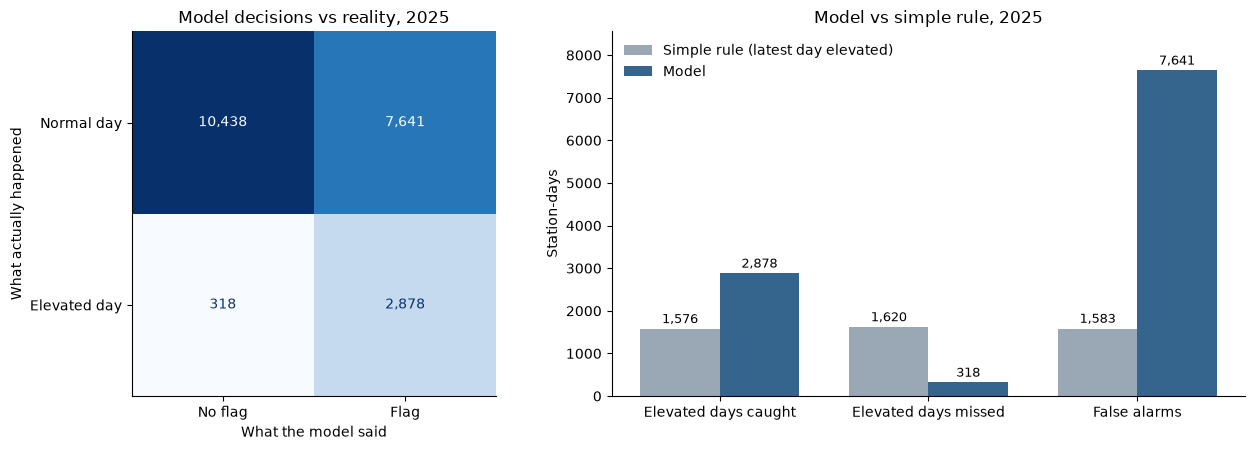

In [10]:
# Stakeholder figure 1: what the model caught, missed and wrongly flagged in 2025
model_pred = (tp >= 0.4).astype(int)
cm_model = confusion_matrix(ty, model_pred, labels=[0, 1])
cm_persist = confusion_matrix(ty, persist, labels=[0, 1])
assert (
    cm_model[1, 1] == 2878 and cm_model[1, 0] == 318 and cm_model[0, 1] == 7641
)  # numbers quoted in the caption
assert cm_persist[1, 1] == 1576 and cm_persist[0, 1] == 1583
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1.35]})
ConfusionMatrixDisplay(cm_model, display_labels=["Normal day", "Elevated day"]).plot(
    ax=ax[0], cmap="Blues", colorbar=False, values_format=",d"
)
ax[0].set(
    title="Model decisions vs reality, 2025", xlabel="What the model said", ylabel="What actually happened"
)
ax[0].set_xticklabels(["No flag", "Flag"])
groups = ["Elevated days caught", "Elevated days missed", "False alarms"]
vals = {
    "Simple rule (latest day elevated)": [cm_persist[1, 1], cm_persist[1, 0], cm_persist[0, 1]],
    "Model": [cm_model[1, 1], cm_model[1, 0], cm_model[0, 1]],
}
x = np.arange(3)
w = 0.38
for k, (label, v) in enumerate(vals.items()):
    bars = ax[1].bar(x + (k - 0.5) * w, v, w, label=label, color=["#9aa7b4", "#35658c"][k])
    ax[1].bar_label(bars, labels=[f"{int(n):,}" for n in v], padding=2, fontsize=9)
ax[1].set_xticks(x, groups)
ax[1].set(title="Model vs simple rule, 2025", ylabel="Station-days")
ax[1].legend(frameon=False)
ax[1].margins(y=0.12)
plt.tight_layout()
plt.show()

**Figure 1. The model catches 9 in 10 elevated days, but most of its flags are false alarms.** Of the 3,196 elevated station-days in 2025, the model flagged 2,878 (90%) and missed 318. The simple rule ("flag tomorrow if the latest available day was elevated") caught only 1,576 (49%). The cost is the number of false alarms: 7,641 for the model against 1,583 for the simple rule. Roughly 3 of every 4 model flags occurred on days that turned out normal. A flag should therefore mean "worth a closer look", not "pollution will be high".

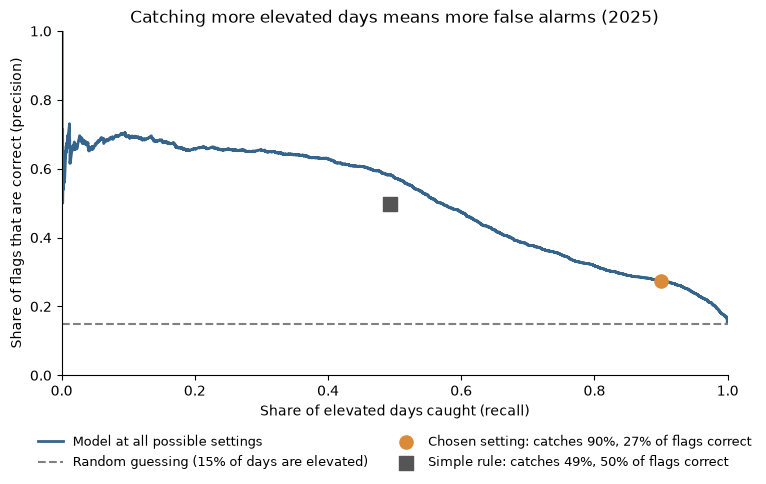

At the simple rule's recall (49.3%), the model can reach precision 58.2% vs 49.9% for the rule.


In [11]:
# Stakeholder figure 2: the trade-off between catching elevated days and avoiding false alarms
precision, recall, _ = precision_recall_curve(ty, tp)
op_p, op_r = precision_score(ty, model_pred), recall_score(ty, model_pred)
pe_p, pe_r = precision_score(ty, persist), recall_score(ty, persist)
assert round(average_precision_score(ty, tp), 2) == 0.51  # quoted in the caption
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall, precision, color="#35658c", lw=2, label="Model at all possible settings")
ax.axhline(ty.mean(), color="grey", ls="--", label=f"Random guessing ({ty.mean():.0%} of days are elevated)")
ax.scatter(
    op_r,
    op_p,
    s=90,
    color="#da8b39",
    zorder=3,
    label=f"Chosen setting: catches {op_r:.0%}, {op_p:.0%} of flags correct",
)
ax.scatter(
    pe_r,
    pe_p,
    s=90,
    marker="s",
    color="#555",
    zorder=3,
    label=f"Simple rule: catches {pe_r:.0%}, {pe_p:.0%} of flags correct",
)
ax.set(
    xlim=(0, 1),
    ylim=(0, 1),
    xlabel="Share of elevated days caught (recall)",
    ylabel="Share of flags that are correct (precision)",
    title="Catching more elevated days means more false alarms (2025)",
)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, fontsize=9)
plt.tight_layout()
plt.show()
same_recall_precision = precision[recall >= pe_r].max()
assert round(same_recall_precision, 3) == 0.582  # quoted in the caption
print(
    f"At the simple rule's recall ({pe_r:.1%}), the model can reach precision {same_recall_precision:.1%} vs {pe_p:.1%} for the rule."
)

**Figure 2. There is no setting that catches every elevated day without many false alarms.** The blue curve shows every possible model setting. Moving right catches more elevated days, but a smaller share of flags are correct. The orange dot is the chosen setting, which was picked in advance on 2024 data to put catching elevated days first. The grey square is the simple rule. The dashed line shows what random guessing would achieve. The model's curve stays well above it: its average precision is 0.51, compared with 0.15 for random guessing. The grey square sits below the curve. At the same detection rate as the simple rule (49%), a stricter model setting would have made about 58% of its flags correct, against 50% for the rule. The model therefore ranks days better than the rule, and the difference between them comes mostly from the chosen setting. This comparison uses 2025 in hindsight, so it is not evidence for picking that setting. A real deployment would need environmental teams to choose a point on this curve, based on how many false alarms they can handle.

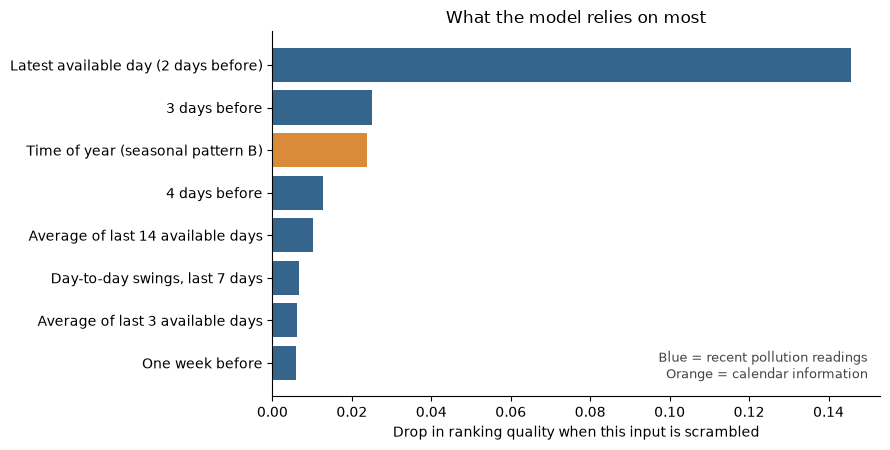

In [12]:
# Stakeholder figure 3: which information the model relies on most (validation 2024)
plain = {
    "pm25_lag_2d": "Latest available day (2 days before)",
    "pm25_lag_3d": "3 days before",
    "pm25_lag_4d": "4 days before",
    "pm25_lag_7d": "One week before",
    "pm25_lag_14d": "Two weeks before",
    "pm25_mean_3d": "Average of last 3 available days",
    "pm25_mean_7d": "Average of last 7 available days",
    "pm25_mean_14d": "Average of last 14 available days",
    "pm25_std_3d": "Day-to-day swings, last 3 days",
    "pm25_std_7d": "Day-to-day swings, last 7 days",
    "pm25_std_14d": "Day-to-day swings, last 14 days",
    "target_year_sin": "Time of year (seasonal pattern A)",
    "target_year_cos": "Time of year (seasonal pattern B)",
    "target_weekday_sin": "Day of week (A)",
    "target_weekday_cos": "Day of week (B)",
    "target_is_weekend": "Weekend",
    "pm25_change_1d": "Change over latest day",
    "pm25_change_7d": "Change over latest week",
    "pm25_trend_3_vs_previous_3d": "Recent 3-day trend",
    "lag2_missing": "Latest day missing",
    "valid_days_3d": "Data completeness, 3 days",
    "valid_days_7d": "Data completeness, 7 days",
    "valid_days_14d": "Data completeness, 14 days",
}
assert imp.idxmax() == "pm25_lag_2d"  # caption relies on this
top = imp.sort_values().tail(8)
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(
    [plain.get(c, c) for c in top.index],
    top.values,
    color=["#35658c" if c.startswith("pm25") else "#da8b39" for c in top.index],
)
ax.set(title="What the model relies on most", xlabel="Drop in ranking quality when this input is scrambled")
ax.text(
    0.98,
    0.05,
    "Blue = recent pollution readings\nOrange = calendar information",
    transform=ax.transAxes,
    ha="right",
    fontsize=9,
    color="#444",
)
plt.tight_layout()
plt.show()

**Figure 3. The model mainly relies on how polluted the air was recently.** The single most useful input is the latest complete day of measurements, which is two days before the forecast day. The next most useful inputs are the few days before that and the time of year. Each bar shows how much worse the model ranks days when that input is shuffled at random. These are statistical associations, not causes. The model has no weather information, so it cannot anticipate an episode that starts suddenly after clean days. Missing weather inputs may contribute to these errors; this hypothesis requires further testing.

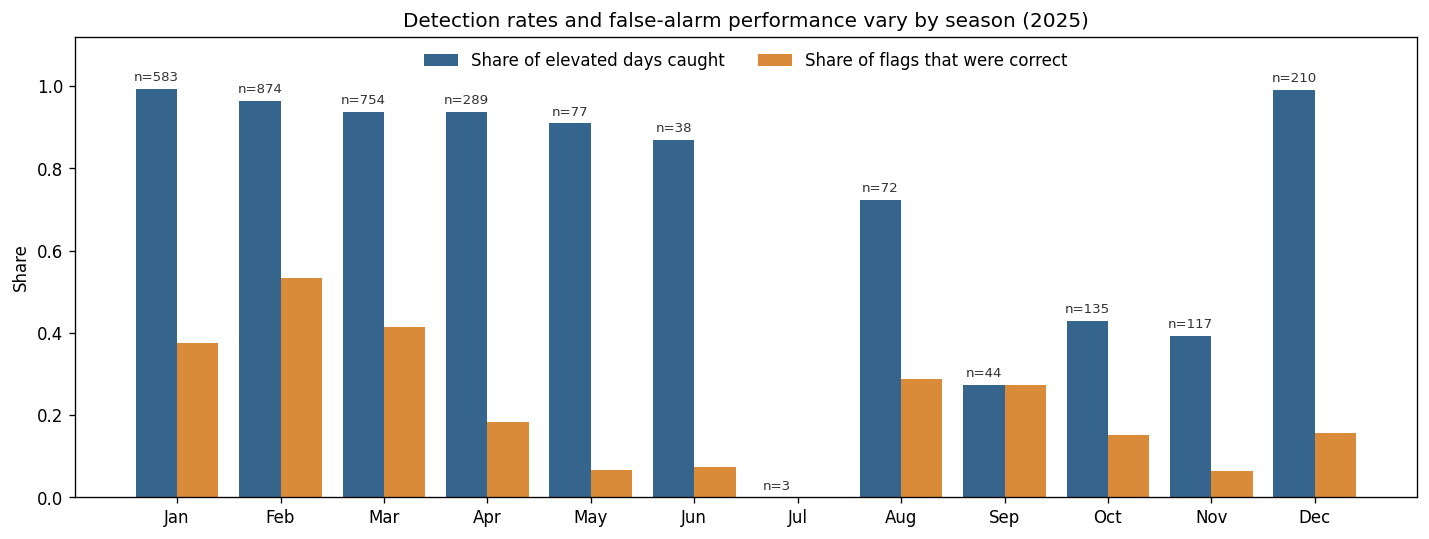

n = number of elevated station-days in that month


In [13]:
# Stakeholder figure 4: performance changes strongly by season (2025 diagnostic, not used for tuning)
d = diagnostic.assign(month=pd.to_datetime(diagnostic.target_date).dt.month)
monthly_view = d.groupby("month").apply(
    lambda g: pd.Series(
        {
            "caught": recall_score(g.target_above_15.astype(int), g.prediction, zero_division=0),
            "correct_flags": precision_score(g.target_above_15.astype(int), g.prediction, zero_division=0),
            "elevated_days": int(g.target_above_15.sum()),
        }
    ),
    include_groups=False,
)
assert (
    round(monthly_view.caught[9], 2) == 0.27 and round(monthly_view.caught[10], 2) == 0.43
)  # quoted in the caption
names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
fig, ax = plt.subplots(figsize=(12, 4.6))
x = np.arange(len(monthly_view))
w = 0.4
b1 = ax.bar(x - w / 2, monthly_view.caught, w, color="#35658c", label="Share of elevated days caught")
ax.bar(x + w / 2, monthly_view.correct_flags, w, color="#da8b39", label="Share of flags that were correct")
for xi, (r, n) in zip(x, zip(monthly_view.caught, monthly_view.elevated_days)):
    ax.text(xi - w / 2, r + 0.02, f"n={int(n)}", ha="center", fontsize=8, color="#333")
ax.set_xticks(x, [names[m - 1] for m in monthly_view.index])
ax.set(
    ylim=(0, 1.12),
    ylabel="Share",
    title="Detection rates and false-alarm performance vary by season (2025)",
)
ax.legend(frameon=False, loc="upper center", ncol=2)
plt.tight_layout()
plt.show()
print("n = number of elevated station-days in that month")

**Figure 4. Reliability depends on the season.** From December to June the model caught 87–99% of elevated days. In September, October and November it caught only 27%, 43% and 39%. July shows zero. Only 3 elevated station-days occurred that month, so this figure is not meaningful on its own. False alarms are most common in late spring and November: in May, June and November fewer than 1 in 10 flags were correct. One likely explanation is the model's dependence on recent readings. Winter pollution often builds up over several days, which makes it easier to anticipate. Episodes in other seasons may start more suddenly, which is a hypothesis that weather data could test. The yearly 90% figure is therefore driven by winter and spring. Without weather inputs, the model should not be relied on in autumn, and any use in that season needs human review. This figure is a diagnostic only. It was not used to change the model or its settings.

### Recommended use and safeguards
Use the capstone as an analytical prototype and evidence for a discussion with environmental teams. Do not use it as an autonomous public-warning service, personal health assessment or replacement for official forecasts. A future pilot needs an agreed alert-volume/precision requirement, meteorological forecast inputs available at cutoff, calibrated scores, live-data replay, human review and prospective evaluation on a fresh period. More years and extreme episodes would help test generalization.

### Personal learning reflection
I learned that a suitable dataset and a precise prediction time matter as much as model choice. Preserving missing dates prevents misleading lag features. High recall can hide a large false-alarm burden, while accuracy can reward ignoring rare events. Responsible impact means communicating these limits clearly and testing an agreed real-world decision, rather than presenting a single score as success.

In [14]:
summary = {
    "primary_model": "Frozen logistic weight 8 threshold 0.40",
    "training_years": [2022, 2023],
    "validation_year": 2024,
    "final_test_year": 2025,
    "original_test_previously_seen": True,
    "new_model_test_status": "exploratory",
    "features": features,
    "rf_validation_choice": str(rf_best.config),
    "rf_threshold": rf_threshold,
    "reduced_threshold": float(reduced_best.threshold),
    "checks": "daily label/calendar, future mutation, training-only preprocessing, frozen prediction confirmation passed",
}
(RESULTS / "capstone_summary.json").write_text(json.dumps(summary, indent=2))
print("Capstone executed. Primary model unchanged; no fitting or tuning uses test data.")
print("Runtime versions:", pd.__version__, np.__version__, __import__("sklearn").__version__)

Capstone executed. Primary model unchanged; no fitting or tuning uses test data.
Runtime versions: 2.2.3 2.3.5 1.8.0


### References and reproducibility

1. IRCEL–CELINE, [open data and attribution](https://www.irceline.be/en/documentation/open-data), accessed 5 October 2026.
2. Belgian official [E1a air-quality reporting](https://cdr.eionet.europa.eu/be/eu/aqd/e1a/); exact files and SHA-256 values in `data/official_source_manifest.json`.
3. Eionet [validity flags](https://dd.eionet.europa.eu/vocabulary/aq/observationvalidity) and [verification flags](https://dd.eionet.europa.eu/vocabulary/aq/observationverification).
4. WHO (2021), [Global air quality guidelines](https://www.who.int/publications/i/item/9789240034228).

Bundled daily data are the authoritative modelling input. The daily audit checks and provenance are included; downloading the full original XML archive is optional for source reconstruction. The notebook contains all modelling code and can run offline after installing `requirements.txt`. Load the bundled joblib only if you trust the project source. Figures are embedded in this notebook. Results CSVs are supplementary; no external report is required for assessment.